In [ ]:
import requests
from pathlib import Path

LIST_URL = "https://prd-tnm.s3.amazonaws.com/CA_FireImpactZone_2025_PRELIMINARY/Palisades/bare_earth/be_rasters/0_file_download_links.txt"
OUT_DIR = Path(r"C:\Users\10981\Desktop\WIF\DEM_raw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("1⃣ 读取清单...")
resp = requests.get(LIST_URL)
resp.raise_for_status()
lines = resp.text.splitlines()

tif_urls = [ln.strip() for ln in lines if ln.strip().lower().endswith(".tif")]

if not tif_urls:
    print("未找到任何 .tif 链接。请确认清单有效。")
    exit(1)

print(f"找到 {len(tif_urls)} 个 DEM 文件，开始下载...")

for url in tif_urls:
    fname = url.split("/")[-1]
    outp = OUT_DIR / fname
    if outp.exists():
        print(f"[跳过] 已存在 {fname}")
        continue
    print(f"[下载] {fname}")
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(outp, "wb") as f:
        for chunk in r.iter_content(chunk_size=1 << 20):
            if chunk:
                f.write(chunk)

print("下载完成。所有 .tif 文件已保存到：")
print(OUT_DIR)


1⃣ 读取清单...
找到 534 个 DEM 文件，开始下载...
[下载] Prelim_11SLT003420037710.tif
[下载] Prelim_11SLT003420037717.tif
[下载] Prelim_11SLT003420037725.tif
[下载] Prelim_11SLT003420037732.tif
[下载] Prelim_11SLT003420037740.tif
[下载] Prelim_11SLT003427037687.tif
[下载] Prelim_11SLT003427037695.tif
[下载] Prelim_11SLT003427037702.tif
[下载] Prelim_11SLT003427037710.tif
[下载] Prelim_11SLT003427037717.tif
[下载] Prelim_11SLT003427037725.tif
[下载] Prelim_11SLT003427037732.tif
[下载] Prelim_11SLT003427037740.tif
[下载] Prelim_11SLT003427037747.tif
[下载] Prelim_11SLT003427037755.tif
[下载] Prelim_11SLT003427037762.tif
[下载] Prelim_11SLT003435037665.tif
[下载] Prelim_11SLT003435037672.tif
[下载] Prelim_11SLT003435037680.tif
[下载] Prelim_11SLT003435037687.tif
[下载] Prelim_11SLT003435037695.tif
[下载] Prelim_11SLT003435037702.tif
[下载] Prelim_11SLT003435037710.tif
[下载] Prelim_11SLT003435037717.tif
[下载] Prelim_11SLT003435037725.tif
[下载] Prelim_11SLT003435037732.tif
[下载] Prelim_11SLT003435037740.tif
[下载] Prelim_11SLT003435037747.tif
[下载] Prelim_1

In [ ]:
from pathlib import Path
import math
import numpy as np
from tqdm import tqdm
import rasterio
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling

WIF_DIR = Path(r"C:\Users\10981\Desktop\WIF")
DEM_RAW_DIR = WIF_DIR / "DEM_raw"      
OUT_ELEV = WIF_DIR / "elevation.tif"
OUT_SLOPE = WIF_DIR / "slope.tif"
OUT_ASPECT = WIF_DIR / "aspect.tif"

TARGET_EPSG = 26911     
TARGET_RES = 30         

def horn_slope_aspect(dem_array, cellsize, nodata):
    """
    用 Horn 3x3 算子计算坡度（%）与坡向（度 0–360，平地=0）
    """
    a = dem_array.astype("float64").copy()
    mask_valid = np.isfinite(a) & (a != nodata)
    a[~mask_valid] = np.nan


    ap = np.pad(a, 1, mode="edge")

    z1 = ap[:-2, :-2]; z2 = ap[:-2, 1:-1]; z3 = ap[:-2, 2:]
    z4 = ap[1:-1, :-2]; z5 = ap[1:-1, 1:-1]; z6 = ap[1:-1, 2:]
    z7 = ap[2:, :-2];  z8 = ap[2:, 1:-1];  z9 = ap[2:, 2:]

    dzdx = ((z3 + 2*z6 + z9) - (z1 + 2*z4 + z7)) / (8.0 * cellsize)
    dzdy = ((z7 + 2*z8 + z9) - (z1 + 2*z2 + z3)) / (8.0 * cellsize)

    grad = np.sqrt(dzdx**2 + dzdy**2)
    slope_pct = grad * 100.0

    aspect = np.degrees(np.arctan2(dzdy, -dzdx))
    aspect = np.where(aspect < 0, 360.0 + aspect, aspect)

    flat = ~np.isfinite(grad) | (grad < 1e-10)
    aspect = np.where(flat, 0.0, aspect)

    slope_pct = np.where(mask_valid, slope_pct, nodata)
    aspect    = np.where(mask_valid, aspect, nodata)
    return slope_pct, aspect

def mosaic_tiles_to_temp(tiles, tmp_path):
    """合并瓦片成一个临时 DEM（保持原始坐标系）"""
    srcs = [rasterio.open(str(p)) for p in tiles]
    mosaic, transform = merge(srcs)
    profile = srcs[0].profile.copy()
    for s in srcs: s.close()

    profile.update(
        height=mosaic.shape[1],
        width=mosaic.shape[2],
        transform=transform,
        count=1,
        compress="deflate",
        predictor=2,
        tiled=True,
        blockxsize=256,
        blockysize=256,
        nodata=profile.get("nodata", None) if profile.get("nodata", None) is not None else -9999,
    )
    with rasterio.open(tmp_path, "w", **profile) as dst:
        dst.write(mosaic[0], 1)

def reproject_to_target(src_path, dst_path, epsg, resolution):
    """重投影/重采样到 EPSG:26911 & 30m"""
    with rasterio.open(src_path) as src:
        dst_crs = rasterio.crs.CRS.from_epsg(epsg)
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds, resolution=resolution
        )
        profile = src.profile.copy()
        profile.update(
            crs=dst_crs,
            transform=transform,
            width=width,
            height=height,
            count=1,
            nodata=src.nodata if src.nodata is not None else -9999,
            dtype=src.dtypes[0],
            compress="deflate",
            predictor=2,
            tiled=True,
            blockxsize=256,
            blockysize=256,
        )
        with rasterio.open(dst_path, "w", **profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear,  # DEM 连续变量
                num_threads=4,
            )

def write_single_band_like(ref_path, out_path, array, dtype="float32", nodata=-9999):
    """按照 ref 栅格的网格写出一个单波段文件"""
    with rasterio.open(ref_path) as ref:
        profile = ref.profile.copy()
    profile.update(dtype=dtype, count=1, nodata=nodata)
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(array.astype(dtype), 1)

def main():
    WIF_DIR.mkdir(parents=True, exist_ok=True)
    assert DEM_RAW_DIR.exists(), f"找不到 DEM 瓦片目录：{DEM_RAW_DIR}"

    tiles = sorted([p for p in DEM_RAW_DIR.glob("*.tif") if p.stat().st_size > 0])
    if not tiles:
        raise SystemExit(f"DEM_raw 下面没有 .tif 瓦片：{DEM_RAW_DIR}")

    print(f"发现 {len(tiles)} 个 DEM 瓦片，开始合并...")
    tmp_native = WIF_DIR / "elevation_native_mosaic.tif"
    mosaic_tiles_to_temp(tiles, tmp_native)
    print(f"已生成临时合并 DEM → {tmp_native}")

    print(f"重投影到 EPSG:{TARGET_EPSG}，分辨率 {TARGET_RES}m ...")
    reproject_to_target(tmp_native, OUT_ELEV, TARGET_EPSG, TARGET_RES)
    tmp_native.unlink(missing_ok=True)
    print(f"elevation.tif 写入完成 → {OUT_ELEV}")

    print("计算坡度 / 坡向 ...")
    with rasterio.open(OUT_ELEV) as src:
        dem = src.read(1)
        nodata = src.nodata if src.nodata is not None else -9999
        cellsize = abs(src.transform.a)

    slope_pct, aspect_deg = horn_slope_aspect(dem, cellsize, nodata)
    write_single_band_like(OUT_ELEV, OUT_SLOPE, slope_pct, "float32", -9999)
    write_single_band_like(OUT_ELEV, OUT_ASPECT, aspect_deg, "float32", -9999)
    print(f"slope.tif → {OUT_SLOPE}")
    print(f"aspect.tif → {OUT_ASPECT}")

    print("\n✅ 全部完成！现在你可以在 FlamMap 里用 elevation/slope/aspect 了。")

if __name__ == "__main__":
    main()


发现 534 个 DEM 瓦片，开始合并...
已生成临时合并 DEM → C:\Users\10981\Desktop\WIF\elevation_native_mosaic.tif
重投影到 EPSG:26911，分辨率 30m ...
elevation.tif 写入完成 → C:\Users\10981\Desktop\WIF\elevation.tif
计算坡度 / 坡向 ...
slope.tif → C:\Users\10981\Desktop\WIF\slope.tif
aspect.tif → C:\Users\10981\Desktop\WIF\aspect.tif

✅ 全部完成！现在你可以在 FlamMap 里用 elevation/slope/aspect 了。


In [ ]:

from pathlib import Path
import zipfile
import numpy as np
from tqdm import tqdm
import requests
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling


WIF_DIR = Path(r"C:\Users\10981\Desktop\WIF")
ELEV_PATH = WIF_DIR / "elevation.tif" 
TMP_DIR = WIF_DIR / "_landfire_tmp"
TMP_DIR.mkdir(parents=True, exist_ok=True)

LF_URL = {
    "FBFM40": "https://landfire.gov/data-downloads/US_230/LF2022_FBFM40_230_CONUS.zip",
    "CC"    : "https://landfire.gov/data-downloads/US_230/LF2022_CC_230_CONUS.zip",
    "CH"    : "https://landfire.gov/data-downloads/US_230/LF2022_CH_230_CONUS.zip",
    "CBH"   : "https://landfire.gov/data-downloads/US_230/LF2022_CBH_230_CONUS.zip",
    "CBD"   : "https://landfire.gov/data-downloads/US_230/LF2022_CBD_230_CONUS.zip",
}

OUT_MAP = {
    "FBFM40": WIF_DIR / "fuel_model.tif",
    "CC"    : WIF_DIR / "canopy_cover.tif",
    "CH"    : WIF_DIR / "canopy_height.tif",
    "CBH"   : WIF_DIR / "canopy_base_height.tif",
    "CBD"   : WIF_DIR / "canopy_bulk_density.tif",
}


LF_LOCAL_TIF = {
    "FBFM40": None,
    "CC"    : None,
    "CH"    : None,
    "CBH"   : None,
    "CBD"   : None,
}


def _download(url: str, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=180) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length") or 0)
        with open(out_path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=out_path.name) as pbar:
            for chunk in r.iter_content(chunk_size=1 << 20):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    return out_path

def _extract_first_tif(zip_path: Path, out_dir: Path) -> Path:
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)
        for n in zf.namelist():
            if n.lower().endswith(".tif"):
                return out_dir / n
    raise RuntimeError(f"No .tif found in {zip_path.name}")

def _load_ref_profile():
    assert ELEV_PATH.exists(), f"找不到基准栅格 {ELEV_PATH}（请先生成 elevation.tif）"
    with rasterio.open(ELEV_PATH) as ref:
        profile = ref.profile.copy()
        aoi_geom = [rasterio.features.shapes(np.ones((ref.height, ref.width), dtype=np.uint8), transform=ref.transform)]
    with rasterio.open(ELEV_PATH) as src:
        aoi = [{
            "type": "Polygon",
            "coordinates": [[
                [src.bounds.left,  src.bounds.top],
                [src.bounds.right, src.bounds.top],
                [src.bounds.right, src.bounds.bottom],
                [src.bounds.left,  src.bounds.bottom],
                [src.bounds.left,  src.bounds.top],
            ]]
        }]
    return profile, aoi

def _reproject_to_match(src_path: Path, dst_path: Path, ref_profile):
    with rasterio.open(src_path) as src:
        dst_profile = ref_profile.copy()
        dst_profile.update(
            dtype=src.profile.get("dtype", "float32"),
            count=1,
            nodata=src.nodata if src.nodata is not None else -9999,
            compress="deflate", predictor=2, tiled=True, blockxsize=256, blockysize=256,
        )
        with rasterio.open(dst_path, "w", **dst_profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_profile["transform"],
                dst_crs=dst_profile["crs"],
                resampling=Resampling.nearest if str(src.dtypes[0]).startswith("int") else Resampling.bilinear,
                num_threads=4,
            )

def _write_array_like(ref_profile, arr, out_path: Path, nodata=-9999, dtype="float32"):
    prof = ref_profile.copy()
    prof.update(dtype=dtype, count=1, nodata=nodata, compress="deflate", predictor=2, tiled=True, blockxsize=256, blockysize=256)
    with rasterio.open(out_path, "w", **prof) as dst:
        dst.write(arr.astype(dtype), 1)


def process_one(key: str, ref_profile, aoi_geom):

    tif_src = LF_LOCAL_TIF.get(key)
    if tif_src:
        tif_src = Path(tif_src)
        if not tif_src.exists():
            raise FileNotFoundError(f"{key} 本地 .tif 不存在：{tif_src}")
    else:
        url = LF_URL[key]
        zip_path = TMP_DIR / url.split("/")[-1]
        if not zip_path.exists():
            print(f"Downloading LANDFIRE {key} ...")
            _download(url, zip_path)
        tif_src = _extract_first_tif(zip_path, TMP_DIR / f"{key}_unz")

  
    aligned_tmp = TMP_DIR / f"{key}_aligned.tif"
    _reproject_to_match(tif_src, aligned_tmp, ref_profile)

    with rasterio.open(aligned_tmp) as src:
        arr = src.read(1)
        nodata = src.nodata if src.nodata is not None else -9999
        arr = np.where(np.isfinite(arr), arr, nodata)

        if key == "CH":  
            finite = arr[arr != nodata]
            if finite.size and np.nanmax(finite) > 150:
                arr = np.where(arr != nodata, arr / 10.0, nodata)

        if key == "CC": 
            arr = np.where((arr != nodata) & (arr < 0), 0, arr)
            arr = np.where((arr != nodata) & (arr > 100), 100, arr)

        if key == "CBD":  
            finite = arr[arr != nodata]
            if finite.size and np.nanmax(finite) > 5:
                arr = np.where(arr != nodata, arr / 100.0, nodata)

      
        out_path = OUT_MAP[key]
        _write_array_like(ref_profile, arr, out_path, nodata=-9999, dtype="float32")
        print(f"{key} → {out_path.name}")

def main():
    ref_profile, aoi_geom = _load_ref_profile()
    order = ["FBFM40", "CC", "CH", "CBH", "CBD"]
    for k in order:
        process_one(k, ref_profile, aoi_geom)

    print("\n✅ 全部完成，输出目录：", WIF_DIR)
    print("现在可以在 FlamMap → Landscape → Build Landscape 里按顺序加载 8 个栅格，创建 .LCP 了。")

if __name__ == "__main__":
    main()


LF2022_FBFM40_230_CONUS.zip: 3.37GB [05:14, 10.7MB/s]


FBFM40 → fuel_model.tif


LF2022_CC_230_CONUS.zip: 1.92GB [03:11, 10.0MB/s]


CC → canopy_cover.tif


LF2022_CH_230_CONUS.zip: 1.81GB [03:05, 9.75MB/s]


CH → canopy_height.tif


LF2022_CBH_230_CONUS.zip: 2.36GB [04:27, 8.82MB/s]


CBH → canopy_base_height.tif


LF2022_CBD_230_CONUS.zip: 1.90GB [03:10, 9.99MB/s]


CBD → canopy_bulk_density.tif

✅ 全部完成，输出目录： C:\Users\10981\Desktop\WIF
现在可以在 FlamMap → Landscape → Build Landscape 里按顺序加载 8 个栅格，创建 .LCP 了。


In [ ]:

import rasterio
from rasterio.merge import merge
from pathlib import Path
import numpy as np

tif_files = [
    r"C:\Users\10981\Desktop\WIF\elevation.tif",
    r"C:\Users\10981\Desktop\WIF\slope.tif",
    r"C:\Users\10981\Desktop\WIF\aspect.tif",
    r"C:\Users\10981\Desktop\WIF\fuel_model.tif",
    r"C:\Users\10981\Desktop\WIF\canopy_cover.tif",
    r"C:\Users\10981\Desktop\WIF\canopy_height.tif",
    r"C:\Users\10981\Desktop\WIF\canopy_base_height.tif",
    r"C:\Users\10981\Desktop\WIF\canopy_bulk_density.tif"
]

out_path = r"C:\Users\10981\Desktop\WIF\landscape_8band.tif"

profiles = []
arrays = []
for i, path in enumerate(tif_files):
    with rasterio.open(path) as src:
        arrays.append(src.read(1))
        profiles.append(src.profile)

profile = profiles[0].copy()
profile.update(
    count=len(tif_files),
    dtype=arrays[0].dtype,
    compress='deflate',
    predictor=2,
    tiled=True,
    blockxsize=256,
    blockysize=256
)

with rasterio.open(out_path, 'w', **profile) as dst:
    for idx, arr in enumerate(arrays, start=1):
        dst.write(arr, idx)

print(f"✅ 已生成8波段GeoTIFF: {out_path}")


✅ 已生成8波段GeoTIFF: C:\Users\10981\Desktop\WIF\landscape_8band.tif


文件信息：
  坐标系: EPSG:26911
  分辨率: (30.0, 30.0)
  波段数: 15
  尺寸 (宽 x 高): 671 x 415

数据统计：
  最小值: 0.0
  最大值: 1.0737629e+16
  平均值: 1785419300000.0


C:\Users\10981\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\10981\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\10981\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\10981\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\10981\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py

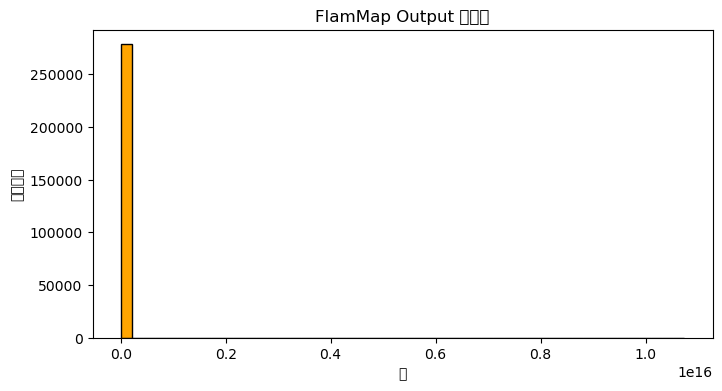

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

tif_path = r"C:\Users\10981\Desktop\WIF\FlamMapOutput.tif"


with rasterio.open(tif_path) as src:
    print("文件信息：")
    print("  坐标系:", src.crs)
    print("  分辨率:", src.res)
    print("  波段数:", src.count)
    print("  尺寸 (宽 x 高):", src.width, "x", src.height)


    data = src.read(1)
    nodata = src.nodata


if nodata is not None:
    data = np.where(data == nodata, np.nan, data)

print("\n数据统计：")
print("  最小值:", np.nanmin(data))
print("  最大值:", np.nanmax(data))
print("  平均值:", np.nanmean(data))


plt.figure(figsize=(8,4))
plt.hist(data[~np.isnan(data)].flatten(), bins=50, color="orange", edgecolor="black")
plt.title("FlamMap Output 值分布")
plt.xlabel("值")
plt.ylabel("像元数量")
plt.show()


CRS: EPSG:26911   分辨率: (30.0, 30.0)   波段数: 15
文件层面的 nodata: -9999.0
[Band 01] 有效像元: 278,437  min=0  max=6.635e+15  mean=7.058e+11  p2=0  p98=36.88


C:\Users\10981\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\10981\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25289 (\N{CJK UNIFIED IDEOGRAPH-62C9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\10981\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20280 (\N{CJK UNIFIED IDEOGRAPH-4F38}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\10981\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\10981\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py

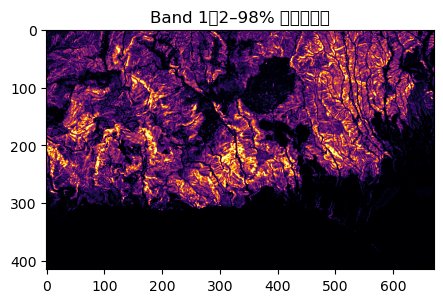

[Band 02] 有效像元: 278,393  min=0  max=2.405e+05  mean=193.7  p2=0  p98=557.2


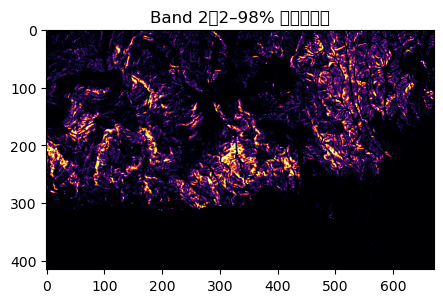

[Band 03] 有效像元: 278,393  min=0  max=2.408e+07  mean=1.544e+04  p2=0  p98=5e+04


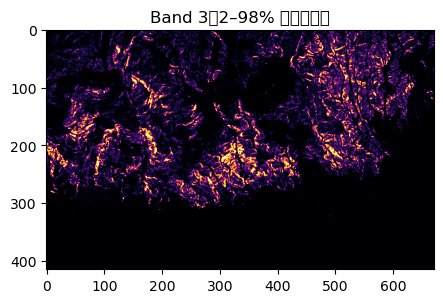

[Band 04] 有效像元: 278,465  min=0  max=2567  mean=689.7  p2=0  p98=2567


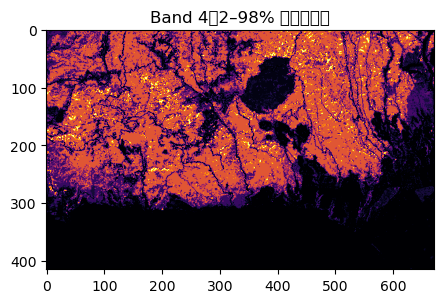

[Band 05] 有效像元: 278,465  min=0  max=1  mean=0.6103  p2=0  p98=1


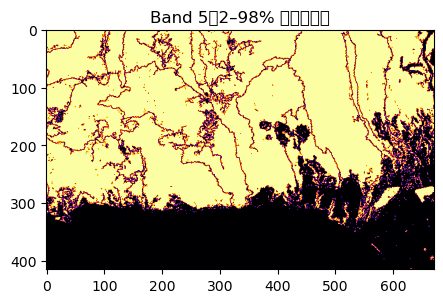

[Band 06] 有效像元: 278,465  min=0  max=0  mean=0  p2=0  p98=0


C:\Users\10981\AppData\Local\Temp\ipykernel_12916\1734307689.py:45: RuntimeWarning: invalid value encountered in divide
  show(np.clip((arr - p2)/(p98 - p2), 0, 1), cmap="inferno")


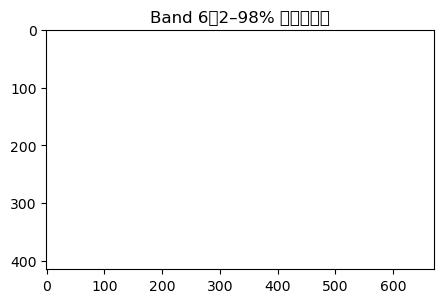

[Band 07] 有效像元: 278,393  min=0  max=4618  mean=31.28  p2=0  p98=196.9


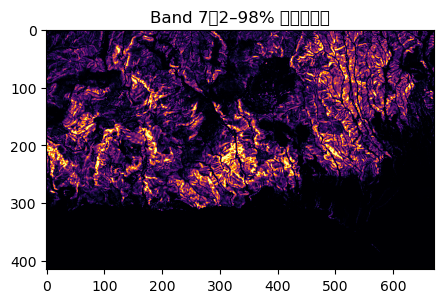

[Band 08] 有效像元: 169,941  min=0.01745  max=6.283  mean=2.861  p2=0.1222  p98=6.178


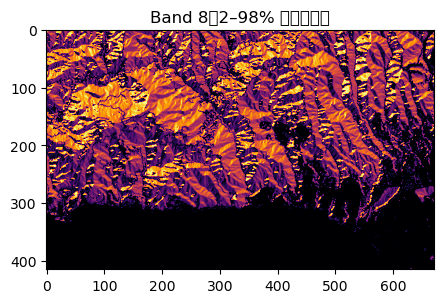

[Band 09] 有效像元: 278,393  min=0  max=1.66e+04  mean=18.25  p2=0  p98=38.46


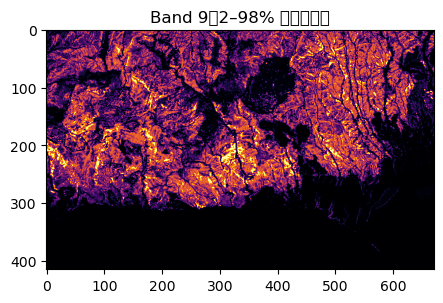

[Band 10] 有效像元: 278,393  min=0  max=1.328e+05  mean=108  p2=0  p98=307.7


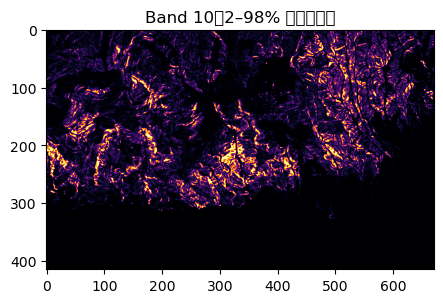

[Band 11] 有效像元: 278,393  min=0  max=1.318e+05  mean=105.1  p2=0  p98=305.2


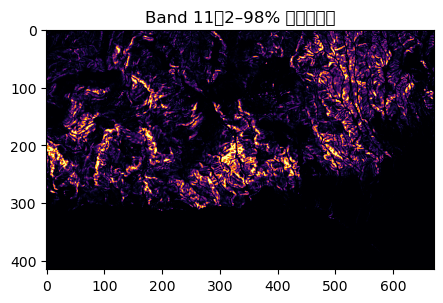

[Band 12] 有效像元: 278,465  min=0  max=0  mean=0  p2=0  p98=0


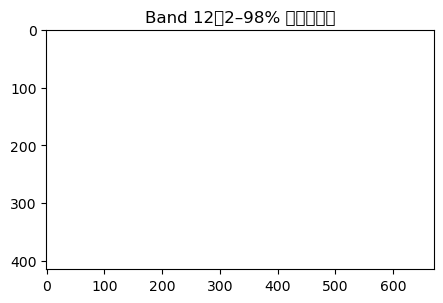

[Band 13] 有效像元: 278,465  min=0  max=0  mean=0  p2=0  p98=0


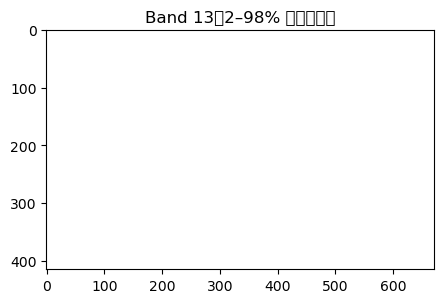

[Band 14] 有效像元: 278,465  min=0  max=0  mean=0  p2=0  p98=0


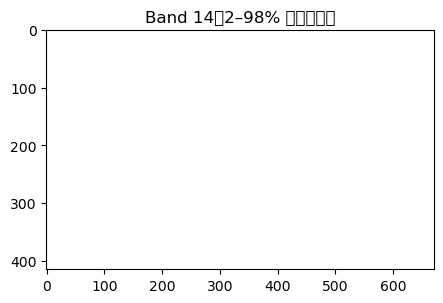

[Band 15] 有效像元: 278,465  min=0  max=0  mean=0  p2=0  p98=0


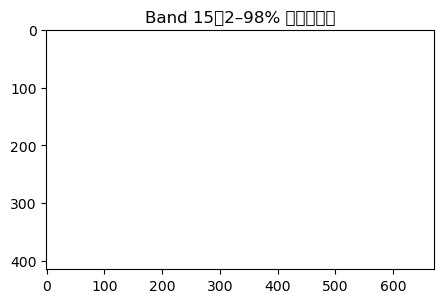


✅ 清洗后的单波段 GeoTIFF 已输出到：C:\Users\10981\Desktop\WIF\flammap_geotiff\clean
提示：接下来用这些干净的 .tif 叠加房屋矢量做统计会更稳。


In [ ]:
import numpy as np
import rasterio
from rasterio.plot import show
from rasterio.enums import Resampling
from pathlib import Path
import matplotlib.pyplot as plt

tif_path = r"C:\Users\10981\Desktop\WIF\FlamMapOutput.tif"
out_dir  = Path(r"C:\Users\10981\Desktop\WIF\flammap_geotiff\clean")
out_dir.mkdir(parents=True, exist_ok=True)

HUGE = [3.4028235e38, 1e30, 1e20, 1e18, 1e16]

with rasterio.open(tif_path) as src:
    print("CRS:", src.crs, "  分辨率:", src.res, "  波段数:", src.count)
    print("文件层面的 nodata:", src.nodata)

    for i in range(1, src.count+1):
        arr = src.read(i).astype("float64")
        nd  = src.nodata

        mask = np.isfinite(arr)
        if nd is not None:
            mask &= (arr != nd)
        for h in HUGE:
            mask &= (np.abs(arr) < h*0.9)  

     
        if not np.any(mask):
            print(f"[Band {i:02d}] 全是无效值（可能未计算或背景）。")
            continue

        valid = arr[mask]
        p2, p98 = np.nanpercentile(valid, [2, 98])

        print(f"[Band {i:02d}] 有效像元: {mask.sum():,}  "
              f"min={np.nanmin(valid):.4g}  max={np.nanmax(valid):.4g}  mean={np.nanmean(valid):.4g}  "
              f"p2={p2:.4g}  p98={p98:.4g}")

        plt.figure(figsize=(5,4))
        plt.title(f"Band {i}（2–98% 拉伸预览）")
        show(np.clip((arr - p2)/(p98 - p2), 0, 1), cmap="inferno")
        plt.show()


        clean = np.where(mask, arr, -9999.0).astype("float32")
        profile = src.profile.copy()
        profile.update(count=1, dtype="float32", nodata=-9999.0,
                       compress="deflate", predictor=2, tiled=True,
                       blockxsize=256, blockysize=256)
        out_path = out_dir / f"Band_{i:02d}.tif"
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(clean, 1)

print(f"\n✅ 清洗后的单波段 GeoTIFF 已输出到：{out_dir}")
print("提示：接下来用这些干净的 .tif 叠加房屋矢量做统计会更稳。")


In [ ]:

import glob, os
from pathlib import Path
import numpy as np
import rasterio

CLEAN_DIR = r"C:\Users\10981\Desktop\WIF\flammap_geotiff\clean"

def guess_label(vmin, vmax, mean, valid_ratio):
    """
    非严格：基于典型范围粗略猜测（单位按你导出的设置，通常是米 & m/min & kW/m）
    - Flame Length（FL）：0–20(米) 常见，平均多在 0–5 之间
    - Rate of Spread（ROS）：0–100+ (m/min) 皆有可能
    - Fireline Intensity（FLI）：0–10000+ (kW/m) 可能很大
    - Crown Fire Activity（CFA）：离散 0/1/2/3（或 0–4），max 很小且为整数
    """

    if valid_ratio < 0.001:
        return "Empty/Background"

    if vmax <= 5 and abs(round(mean) - mean) < 1e-6:
        return "CrownFireActivity?"

    if vmax <= 60 and mean < 10:
        return "FlameLength?"

    if vmax <= 500 and mean < 50:
        return "RateOfSpread?"

    if vmax > 1000:
        return "FirelineIntensity?"

    return "Unknown"

def main():
    tifs = sorted(glob.glob(os.path.join(CLEAN_DIR, "Band_*.tif")))
    if not tifs:
        print("未找到 Band_*.tif，请先运行清洗脚本得到按波段拆分后的文件。")
        return

    print(f"Found {len(tifs)} bands under: {CLEAN_DIR}\n")
    candidates = {}
    for tif in tifs:
        with rasterio.open(tif) as src:
            arr = src.read(1)
            nd = src.nodata
            mask = np.isfinite(arr) & ((nd is None) | (arr != nd))
            valid = arr[mask]
            total = arr.size
            if valid.size == 0:
                vmin = vmax = mean = np.nan
                ratio = 0.0
            else:
                vmin = float(np.nanmin(valid))
                vmax = float(np.nanmax(valid))
                mean = float(np.nanmean(valid))
                ratio = valid.size / total

        label = guess_label(vmin, vmax, mean, ratio)
        name = Path(tif).name
        print(f"{name:>10s} | valid {valid.size:>7d}/{total:<7d} ({ratio:5.1%}) | "
              f"min={vmin:8.3g}  max={vmax:8.3g}  mean={mean:8.3g}  -> {label}")

        candidates[name] = label

    print("\n提示：优先找出 FlameLength? 的那个波段；"
          "若有需要，再找 RateOfSpread?、FirelineIntensity?、CrownFireActivity?。")
    print("确认好波段编号后，把编号填到下面第②段脚本里跑房屋损伤。")

if __name__ == "__main__":
    main()


Found 15 bands under: C:\Users\10981\Desktop\WIF\flammap_geotiff\clean

Band_01.tif | valid  278437/278465  (100.0%) | min=       0  max=6.63e+15  mean=7.06e+11  -> FirelineIntensity?
Band_02.tif | valid  278393/278465  (100.0%) | min=       0  max=2.41e+05  mean=     194  -> FirelineIntensity?
Band_03.tif | valid  278393/278465  (100.0%) | min=       0  max=2.41e+07  mean=1.54e+04  -> FirelineIntensity?
Band_04.tif | valid  278465/278465  (100.0%) | min=       0  max=2.57e+03  mean=     690  -> FirelineIntensity?
Band_05.tif | valid  278465/278465  (100.0%) | min=       0  max=       1  mean=    0.61  -> FlameLength?
Band_06.tif | valid  278465/278465  (100.0%) | min=       0  max=       0  mean=       0  -> CrownFireActivity?
Band_07.tif | valid  278393/278465  (100.0%) | min=       0  max=4.62e+03  mean=    31.3  -> FirelineIntensity?
Band_08.tif | valid  169941/278465  (61.0%) | min=  0.0175  max=    6.28  mean=    2.86  -> FlameLength?
Band_09.tif | valid  278393/278465  (100.0%) 

In [ ]:

from pathlib import Path
import rasterio
from rasterio.warp import reproject, Resampling

WIF = Path(r"C:\Users\10981\Desktop\WIF")
REF = WIF / "elevation.tif"               
FL_IN  = WIF / "flammap_geotiff" / "clean" / "Band_08.tif"  # Flame Length
FLI_IN = WIF / "flammap_geotiff" / "clean" / "Band_07.tif"  # Fireline Intensity

OUT_DIR = WIF / "flammap_geotiff" / "aligned"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FL_OUT  = OUT_DIR / "FlameLength_aligned.tif"
FLI_OUT = OUT_DIR / "FirelineIntensity_aligned.tif"

def align_one(src_path: Path, ref_path: Path, out_path: Path, resampling: Resampling):
    with rasterio.open(ref_path) as ref:
        dst_profile = ref.profile.copy()
       
        dst_profile.update(
            driver="GTiff", count=1,
            compress="deflate", predictor=2, tiled=True,
            blockxsize=256, blockysize=256,
            nodata=ref.nodata if ref.nodata is not None else -9999,
        )

    with rasterio.open(src_path) as src, rasterio.open(out_path, "w", **dst_profile) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_profile["transform"],
            dst_crs=dst_profile["crs"],
            resampling=resampling,
            num_threads=4,
        )
    print(f"✓ 写出：{out_path}")

def main():
    align_one(FL_IN,  REF, FL_OUT,  Resampling.bilinear)
    align_one(FLI_IN, REF, FLI_OUT, Resampling.bilinear)
    print("\n完成！输出目录：", OUT_DIR)

if __name__ == "__main__":
    main()


✓ 写出：C:\Users\10981\Desktop\WIF\flammap_geotiff\aligned\FlameLength_aligned.tif
✓ 写出：C:\Users\10981\Desktop\WIF\flammap_geotiff\aligned\FirelineIntensity_aligned.tif

完成！输出目录： C:\Users\10981\Desktop\WIF\flammap_geotiff\aligned
